# EDA: Arriendo de propiedades

Análisis exploratorio del segmento **arriendo** a partir de los datos normalizados. El objetivo del modelo es `precio_clp_normalizado` (renta mensual en CLP).

## Setup

Carga los datos normalizados.

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

from src.eda.leer import cargar_properties

sns.set_theme(style="whitegrid", palette="muted")
PALETA = sns.color_palette()

df = cargar_properties(tipo_operacion="arriendo")
print(f"Total de publicaciones: {len(df)} arriendos")

Total de publicaciones: 3330 arriendos


## Vista general

Dimensiones, tipos y primeras filas del segmento.

In [84]:
df.shape

(3330, 21)

In [85]:
df.dtypes

id                                int64
fuente                              str
url_origen                          str
tipo_operacion                      str
tipo_propiedad                      str
precio_valor                    float64
precio_moneda                       str
precio_clp_normalizado          float64
m2_util                         float64
m2_total                        float64
gastos_comunes                  float64
dormitorios                     float64
banos                           float64
estacionamientos                float64
bodega                          boolean
comuna                              str
region                              str
antiguedad_anios                float64
descripcion                         str
fecha_publicacion         datetime64[s]
fecha_scraping            datetime64[s]
dtype: object

In [86]:
df.head()

,id,fuente,url_origen,tipo_operacion,tipo_propiedad,precio_valor,precio_moneda,precio_clp_normalizado,m2_util,m2_total,...,dormitorios,banos,estacionamientos,bodega,comuna,region,antiguedad_anios,descripcion,fecha_publicacion,fecha_scraping
0,529,portal_inmobiliario,https://portalinmobiliario.com/MLC-1975380243-...,arriendo,casa,1400000.0,CLP,1400000.0,120.0,120.0,...,3.0,4.0,NaN,<NA>,Concepción,NaN,NaN,NaN,NaT,2026-08-30
1,867,portal_inmobiliario,https://portalinmobiliario.com/MLC-1983489803-...,arriendo,departamento,650000.0,CLP,650000.0,53.0,53.0,...,2.0,2.0,NaN,<NA>,Machalí,NaN,NaN,NaN,NaT,2026-08-30
2,790,portal_inmobiliario,https://portalinmobiliario.com/MLC-2006062703-...,arriendo,departamento,550000.0,CLP,550000.0,48.0,48.0,...,2.0,2.0,NaN,<NA>,Macul,NaN,NaN,NaN,NaT,2026-08-30
3,499,portal_inmobiliario,https://portalinmobiliario.com/MLC-2024978025-...,arriendo,casa,3700000.0,CLP,3700000.0,1365.0,1365.0,...,6.0,2.0,NaN,<NA>,Talcahuano,NaN,NaN,NaN,NaT,2026-08-30
4,802,portal_inmobiliario,https://portalinmobiliario.com/MLC-2031485581-...,arriendo,departamento,280000.0,CLP,280000.0,30.0,30.0,...,1.0,1.0,NaN,<NA>,Santiago,NaN,NaN,NaN,NaT,2026-08-30


## Calidad de datos

Porcentaje de valores nulos por columna y comprobación de duplicados.

In [87]:
nulos = df.isna().mean().mul(100).sort_values(ascending=False)
pd.DataFrame({'%_nulos': nulos})

,%_nulos
gastos_comunes,100.000000
bodega,99.879880
antiguedad_anios,98.198198
descripcion,97.057057
region,97.057057
estacionamientos,94.684685
m2_util,39.129129
fecha_publicacion,23.423423
m2_total,8.048048
dormitorios,1.771772


In [88]:
dup = df.duplicated(subset=['fuente', 'url_origen']).sum()
print('Duplicados por (fuente, url_origen):', dup)

Duplicados por (fuente, url_origen): 0


## Distribución del precio (objetivo)

El objetivo del modelo de valoración es `precio_clp_normalizado` (CLP). Se analiza solo sobre avisos con precio válido (> 0).

In [89]:
precio = df['precio_clp_normalizado'].dropna()
precio = precio[precio > 0]
print('Avisos con precio válido:', len(precio), '/', len(df))
precio.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

Avisos con precio válido: 3328 / 3330


count    3.328000e+03
mean     1.317624e+07
std      4.160994e+08
min      3.921956e+04
1%       2.213500e+05
5%       2.893500e+05
25%      4.200000e+05
50%      6.500000e+05
75%      1.400000e+06
95%      4.442250e+06
99%      8.219801e+06
max      1.716532e+10
Name: precio_clp_normalizado, dtype: float64

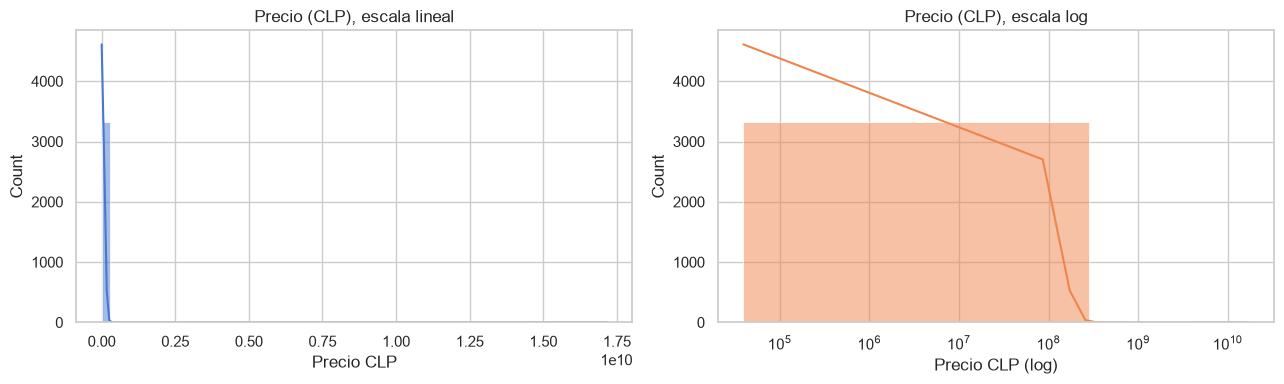

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(precio, bins=60, kde=True, ax=axes[0], color=PALETA[0])
axes[0].set_title('Precio (CLP), escala lineal')
axes[0].set_xlabel('Precio CLP')
sns.histplot(precio, bins=60, kde=True, ax=axes[1], color=PALETA[1])
axes[1].set_xscale('log')
axes[1].set_title('Precio (CLP), escala log')
axes[1].set_xlabel('Precio CLP (log)')
plt.tight_layout(); plt.show()

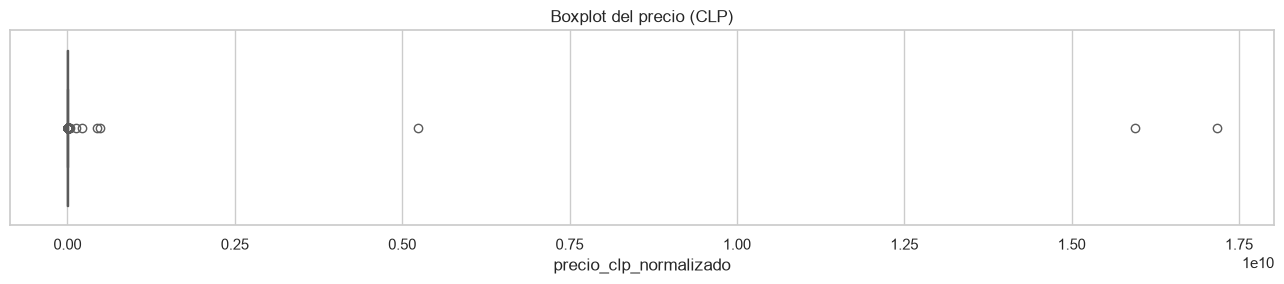

In [91]:
fig, ax = plt.subplots(figsize=(13, 3))
sns.boxplot(x=precio, ax=ax, color=PALETA[2])
ax.set_title('Boxplot del precio (CLP)')
plt.tight_layout(); plt.show()

## Precio por m²

Rasgo derivado clave para la valoración: precio CLP por m² útil y por m² total.

In [92]:
relevante = df[
    df['precio_clp_normalizado'].gt(0)
    & df['m2_util'].gt(0)
    & df['m2_total'].gt(0)
].copy()
relevante['precio_por_m2_util'] = (
    relevante['precio_clp_normalizado'] / relevante['m2_util']
)
relevante['precio_por_m2_total'] = (
    relevante['precio_clp_normalizado'] / relevante['m2_total']
)
print('Avisos con m2 util y total:', len(relevante))
relevante[['precio_por_m2_util', 'precio_por_m2_total']].describe()

Avisos con m2 util y total: 2025


,precio_por_m2_util,precio_por_m2_total
count,2.025000e+03,2.025000e+03
mean,3.413568e+04,3.350321e+04
std,9.472524e+05,9.473088e+05
min,3.733333e+01,3.733333e+01
25%,8.000000e+03,7.142857e+03
50%,9.818182e+03,9.375000e+03
75%,1.223690e+04,1.166667e+04
max,4.251748e+07,4.251748e+07


## Variables numéricas

Estadísticos y histogramas de las características numéricas.

In [93]:
numericas = ['m2_util', 'm2_total', 'gastos_comunes', 'dormitorios',
             'banos', 'estacionamientos', 'antiguedad_anios']
df[numericas].describe()

,m2_util,m2_total,gastos_comunes,dormitorios,banos,estacionamientos,antiguedad_anios
count,2027.000000,3062.000000,0.0,3271.000000,3303.000000,177.000000,60.000000
mean,212.124578,546.474389,NaN,2.759095,2.224342,1.813559,27.833333
std,646.234304,2506.500449,NaN,1.957825,1.733166,1.478727,18.026503
min,1.000000,1.000000,NaN,1.000000,1.000000,1.000000,3.000000
25%,45.000000,45.000000,NaN,2.000000,1.000000,1.000000,14.000000
50%,71.000000,73.000000,NaN,2.000000,2.000000,1.000000,27.000000
75%,147.500000,200.000000,NaN,3.000000,3.000000,2.000000,37.250000
max,10000.000000,75000.000000,NaN,36.000000,37.000000,10.000000,76.000000


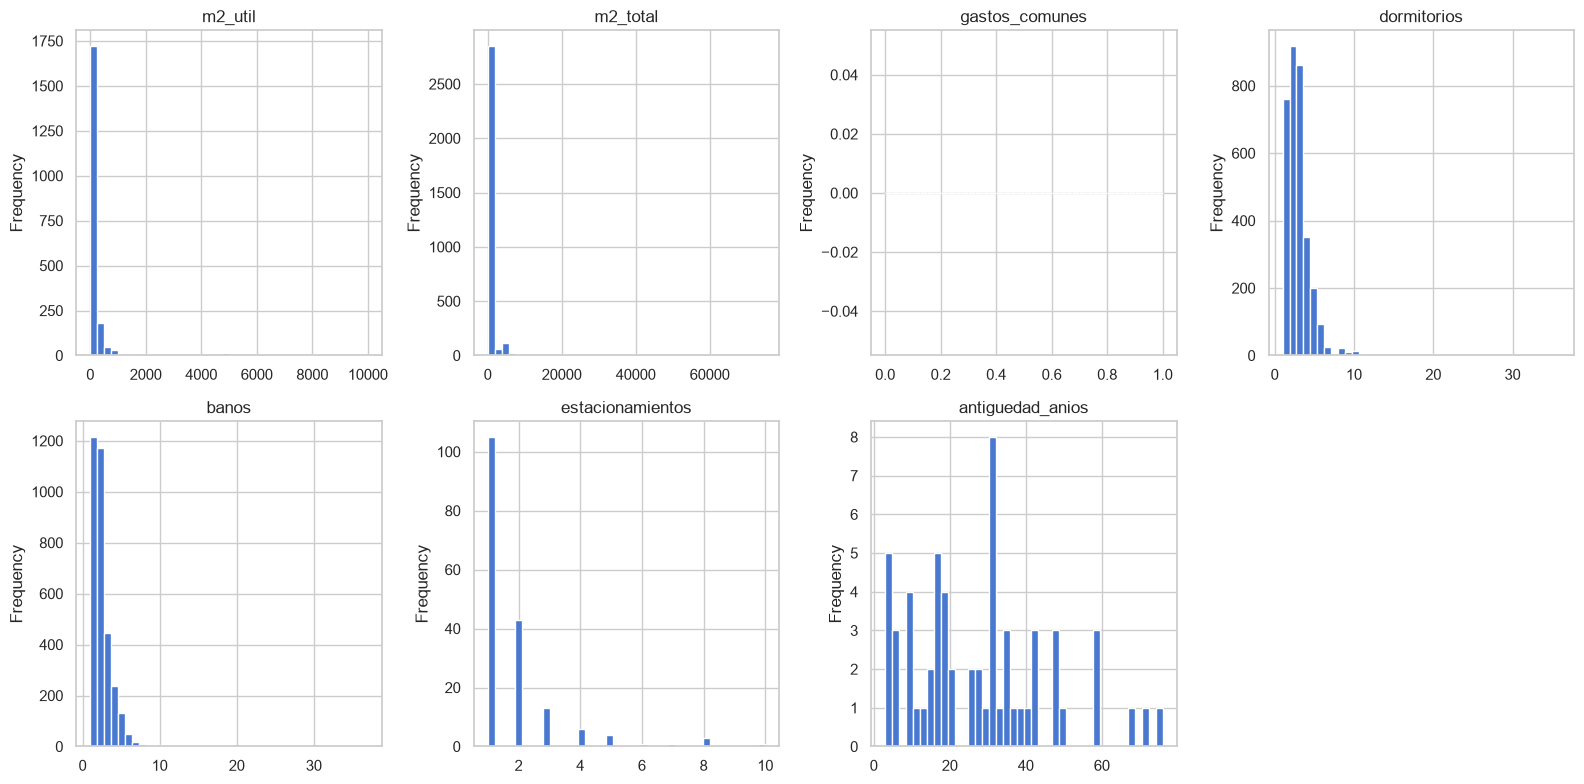

In [94]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numericas):
    valores = df[col].dropna()
    valores.plot.hist(bins=40, ax=axes[i], title=col)
    axes[i].set_xlabel('')
for j in range(len(numericas), len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

In [95]:
print('Relación con el precio (Spearman), con precio válido:')
con_precio = df[
    df['precio_clp_normalizado'].gt(0)
]
for col in ['m2_util', 'm2_total', 'dormitorios', 'banos',
            'estacionamientos', 'antiguedad_anios']:
    validos = con_precio[[col, 'precio_clp_normalizado']].dropna()
    if len(validos) > 2:
        rho, p = stats.spearmanr(
            validos[col], validos['precio_clp_normalizado']
        )
        print(f'{col:18s} n={len(validos):5d} rho={rho:+.3f}')
    else:
        print(f'{col:18s} sin suficientes datos')

Relación con el precio (Spearman), con precio válido:
m2_util            n= 2026 rho=+0.872
m2_total           n= 3061 rho=+0.823
dormitorios        n= 3269 rho=+0.730
banos              n= 3301 rho=+0.797
estacionamientos   n=  176 rho=+0.418
antiguedad_anios   n=   60 rho=+0.376


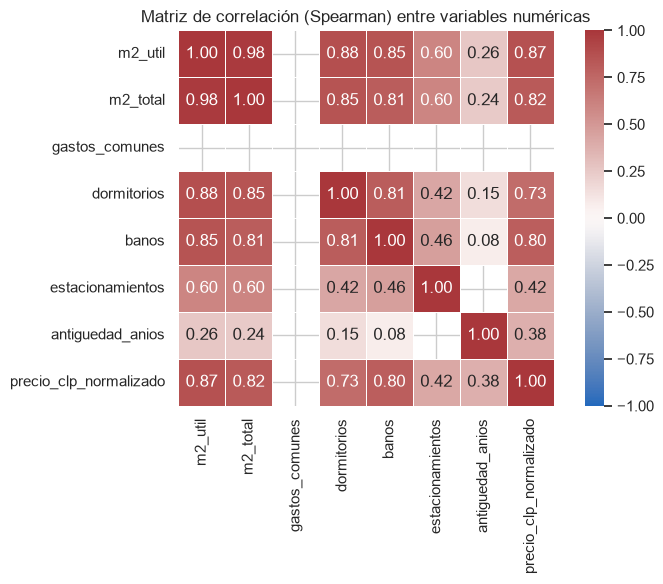

In [96]:
cols_corr = numericas + ['precio_clp_normalizado']
corr = con_precio[cols_corr].corr(method='spearman')
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='vlag', center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5
)
plt.title('Matriz de correlación (Spearman) entre variables numéricas')
plt.tight_layout(); plt.show()

## Precio vs. m² útil

Scatter precio ~ m² útil, coloreado por tipo de propiedad, para ver la forma de la relación.

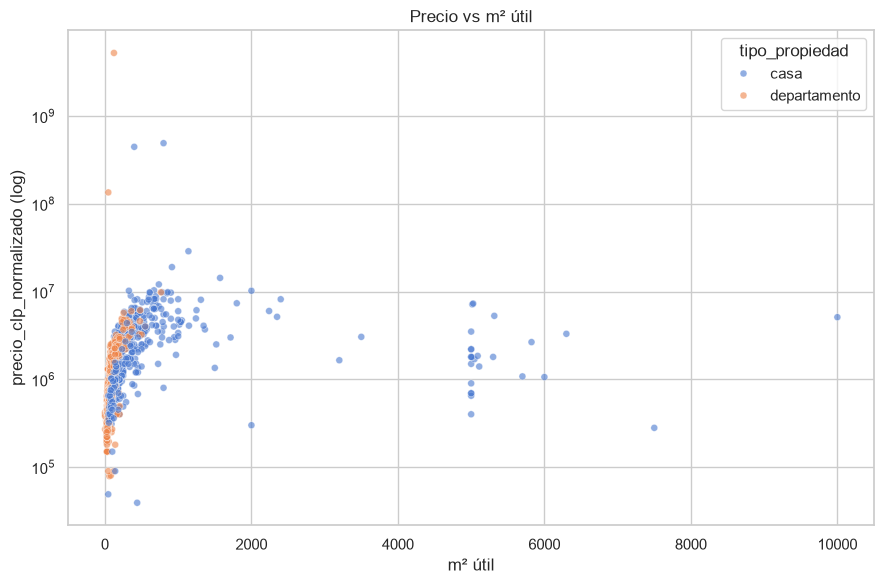

In [97]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=relevante, x='m2_util', y='precio_clp_normalizado',
    hue='tipo_propiedad', alpha=0.6, s=25
)
plt.yscale('log')
plt.xlabel('m² útil'); plt.ylabel('precio_clp_normalizado (log)')
plt.title('Precio vs m² útil')
plt.tight_layout(); plt.show()

## Variables categóricas

Distribución por fuente, tipo de propiedad y comuna, y precio medio por comuna (las comunas con más avisos).

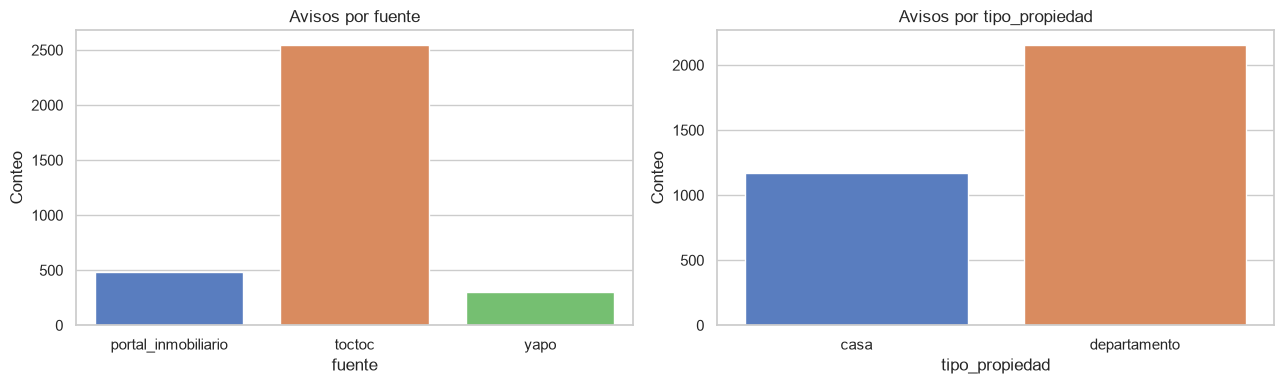

In [98]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x='fuente', hue='fuente', legend=False, ax=ax[0], palette='muted')
ax[0].set_title('Avisos por fuente')
ax[0].set_xlabel('fuente'); ax[0].set_ylabel('Conteo')
sns.countplot(data=df, x='tipo_propiedad', hue='tipo_propiedad', legend=False, ax=ax[1], palette='muted')
ax[1].set_title('Avisos por tipo_propiedad')
ax[1].set_xlabel('tipo_propiedad'); ax[1].set_ylabel('Conteo')
plt.tight_layout(); plt.show()

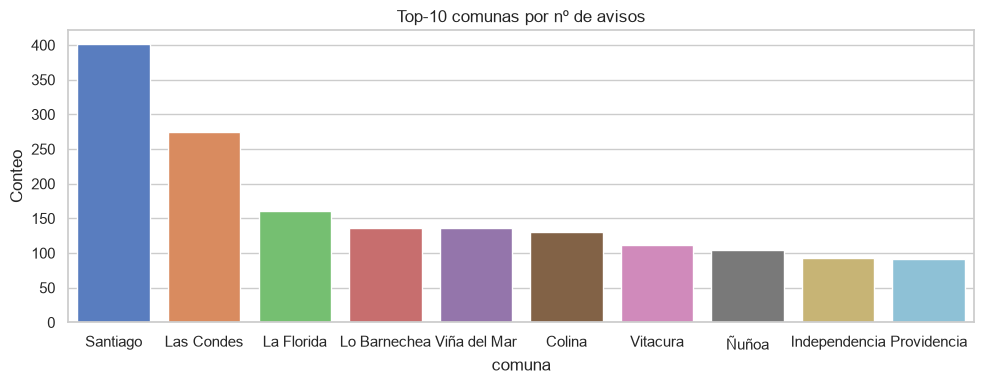

In [99]:
top_comunas = df['comuna'].value_counts().head(10)
plt.figure(figsize=(10, 4))
sns.barplot(x=top_comunas.index, y=top_comunas.values, hue=top_comunas.index, legend=False, palette='muted')
plt.title('Top-10 comunas por nº de avisos')
plt.xlabel('comuna'); plt.ylabel('Conteo')
plt.tight_layout(); plt.show()

In [100]:
precio_por_comuna = (
    con_precio.groupby('comuna')['precio_clp_normalizado']
    .agg([('n', 'count'), ('mediana', 'median')])
    .sort_values('n', ascending=False)
    .head(10)
)
precio_por_comuna

,n,mediana
comuna,,
Santiago,401,355000.000
Las Condes,274,1757005.585
La Florida,160,432500.000
Lo Barnechea,136,4316294.600
Viña del Mar,136,690000.000
Colina,130,2444336.500
Vitacura,112,2500083.885
Ñuñoa,105,620000.000
Independencia,93,340000.000


In [101]:
precio_por_fuente = (
    con_precio.groupby('fuente')['precio_clp_normalizado']
    .agg([('n', 'count'), ('mediana', 'median')])
)
precio_por_fuente

,n,mediana
fuente,,
portal_inmobiliario,480,785000.0
toctoc,2549,650000.0
yapo,299,500000.0


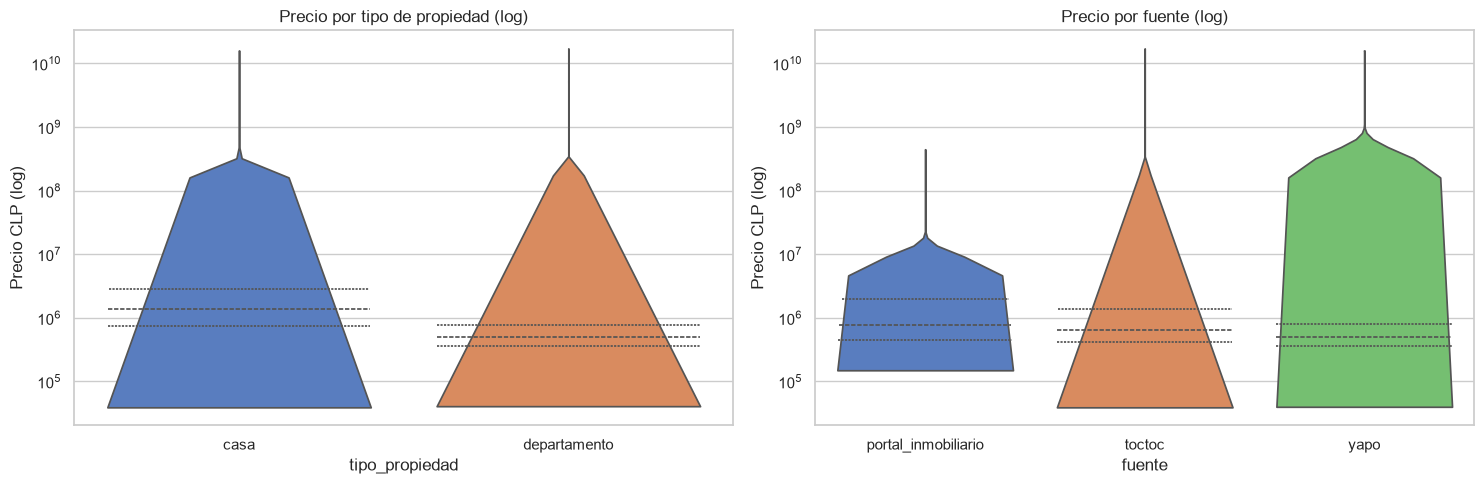

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.violinplot(
    data=con_precio, x='tipo_propiedad', y='precio_clp_normalizado',
    ax=axes[0], hue='tipo_propiedad', legend=False, inner='quart', cut=0
)
axes[0].set_yscale('log')
axes[0].set_title('Precio por tipo de propiedad (log)')
axes[0].set_xlabel('tipo_propiedad'); axes[0].set_ylabel('Precio CLP (log)')
sns.violinplot(
    data=con_precio, x='fuente', y='precio_clp_normalizado',
    ax=axes[1], hue='fuente', legend=False, inner='quart', cut=0
)
axes[1].set_yscale('log')
axes[1].set_title('Precio por fuente (log)')
axes[1].set_xlabel('fuente'); axes[1].set_ylabel('Precio CLP (log)')
plt.tight_layout(); plt.show()

In [103]:
fig = px.scatter(
    relevante,
    x='m2_util', y='precio_clp_normalizado',
    color='tipo_propiedad',
    size='precio_clp_normalizado',
    hover_data=['comuna', 'fuente', 'dormitorios', 'banos'],
    log_y=True, opacity=0.6, title='Precio vs m² útil (interactivo)'
)
fig.update_layout(template='plotly_white', legend_title='tipo_propiedad')
fig.show()

In [104]:
fig = px.box(
    con_precio[con_precio['comuna'].isin(top_comunas.index)],
    x='comuna', y='precio_clp_normalizado', color='tipo_propiedad',
    log_y=True, title='Precio por comuna (top 10, interactivo)'
)
fig.update_layout(
    template='plotly_white',
    xaxis_title='comuna', yaxis_title='Precio CLP (log)'
)
fig.show()

In [105]:
fig = px.histogram(
    con_precio, x='precio_clp_normalizado', color='tipo_propiedad',
    log_x=True, marginal='box', nbins=60,
    title='Distribución de precio por tipo de propiedad (interactivo)'
)
fig.update_layout(
    template='plotly_white',
    xaxis_title='Precio CLP (log)', yaxis_title='Conteo'
)
fig.show()

## Hallazgos e implicaciones para el modelado

Resumen de lo observado y recomendaciones de cara a la ingeniería de variables (`src/features/`) y al modelo.

### Distribución del precio
- Media CLP 13.2M **inflada por outliers** vs mediana CLP 650K, con max CLP 17.2B → modelar `log1p(precio)` usando mediana como referencia.

### Calidad de datos
- Casi inutilizables por nulos: `gastos_comunes` **(100%)**, `bodega` (99.9%), `antiguedad_anios` (98.2%), `descripcion` (97%), `region` (97%), `estacionamientos` (94.7%).
- Moderados: `m2_util` (39.1%), `fecha_publicacion` (23.4%), `m2_total` (8%).
- Sólidas: precios, `comuna`, `tipo_propiedad`, `dormitorios` (1.8%), `banos` (0.8%).

### Correlación con el precio (Spearman)
- Fuerte (más que en venta): `m2_util` (0.872), `m2_total` (0.823), `banos` (0.797), `dormitorios` (0.730).
- Débil/poco fiable por bajo n: `estacionamientos` (0.418, n=176) y `antiguedad_anios` (0.376, n=60).

### Geografía
- Top comunas: Santiago (401), Las Condes (274), La Florida (160).
- Mediana de renta muy dispar: Lo Barnechea CLP 4.32M/mes vs Santiago CLP 355K → la **comuna explica gran parte de la variación** del precio por m².

### Fuente
- toctoc domina (2549), luego portal_inmobiliario (480) y yapo (299).
- Medianas de renta distintas por fuente: yapo CLP 500K, toctoc CLP 650K, PI CLP 785K → **posible sesgo de fuente/segmento**.

### Corrección por hallazgo
- Se creia que `gastos_comunes` era frecuente en arriendo; el EDA muestra que está **100% nulo**. Debe desestimarse como feature.

### Recomendaciones
- Modelar `log1p(precio_clp_normalizado)` y revisar outliers (max CLP 17.2B).
- Imputar nulos de `m2_total`/`m2_util` por comuna/tipo_propiedad (más urgente que en venta, 39% nulo en m2_util).
- Validación estratificada por comuna y fuente.
